In [1]:
from kan import *

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = KAN(width=[2,5,1], grid=5, k=3, seed=0,device=device)

checkpoint directory created: ./model
saving model version 0.0


#### Data source: https://www.kaggle.com/datasets/nikunjhemani/freddie-macs-dataset-pre-processed/code
#### Feature selection: https://www.kaggle.com/code/missionjee/feature-selection

In [2]:
import pandas as pd

# Load your dataset
df = pd.read_csv('FreddieMac.csv')
df['LTV_range'] = df['LTV_range'].map({'Low': 1, 'Medium': 2, 'High':3})
df['FirstPayment_Year'] = df['FirstPayment_Year'] - df['FirstPayment_Year'].min() + 1
# Select features and target variable
'''features = df[['Repay_range', 'LTV_range', 'FirstTimeHomebuyer', 'NumBorrowers','MonthsInRepayment', 'OrigUPB', 
               'OrigInterestRate', 'MIP', 'Maturity_Year', 'FirstPayment_Year','MSA', 'DTI']].values'''    
features = df[['FirstPayment_Year', 'MIP']].values     
    
# features = features.fillna(features.mean()).values # replace the null value with the mean
target = df['Credit_range'].map({'Poor': -1, 'Fair': 0, 'Good': 1}).values

'''scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)'''

# Convert to PyTorch tensors
train_input = torch.tensor(features, dtype=torch.float32).to(device)
train_label = torch.tensor(target, dtype=torch.float32).to(device)

# Create dataset dictionary similar to the original example
dataset = {
    'train_input': train_input,
    'train_label': train_label,
    'test_input': train_input.clone(),  # Use the training data as the test data
    'test_label': train_label.clone()
}
# The shapes will show the dimensions of your data
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([148938, 2]), torch.Size([148938]))

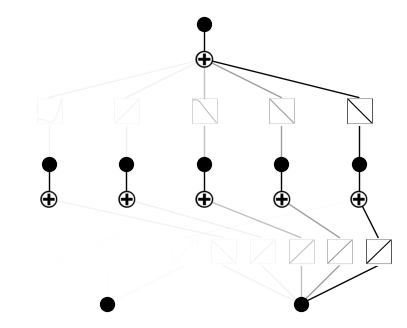

In [3]:
dataset = {
    'train_input': dataset['train_input'][:3000],
    'train_label': dataset['train_label'][:3000],
    'test_input': dataset['test_input'][:3000],
    'test_label': dataset['test_label'][:3000]
}

# plot KAN at initialization
model(dataset['train_input']);
model.plot();
# model.plot(beta=100,sample=True)

| train_loss: 5.31e-01 | test_loss: 5.31e-01 | reg: 2.34e+00 | : 100%|█| 50/50 [02:16<00:00,  2.73s/


saving model version 0.1


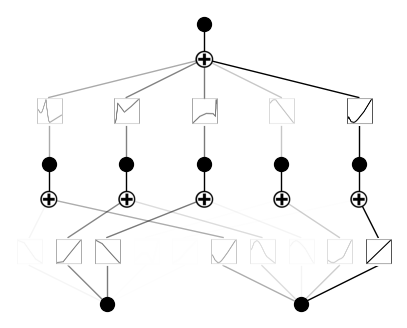

In [4]:
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001);
model.plot()

saving model version 0.2


| train_loss: 5.34e-01 | test_loss: 5.34e-01 | reg: 8.28e+00 | : 100%|█| 50/50 [01:15<00:00,  1.51s/

saving model version 0.3


{'train_loss': [array(0.53902, dtype=float32),
  array(0.53628814, dtype=float32),
  array(0.5353809, dtype=float32),
  array(0.5353282, dtype=float32),
  array(0.5353282, dtype=float32),
  array(0.5353282, dtype=float32),
  array(0.5353282, dtype=float32),
  array(0.5345491, dtype=float32),
  array(0.53473747, dtype=float32),
  array(0.53471917, dtype=float32),
  array(0.5347148, dtype=float32),
  array(0.5347148, dtype=float32),
  array(0.5347148, dtype=float32),
  array(0.5347148, dtype=float32),
  array(0.53462213, dtype=float32),
  array(0.53459543, dtype=float32),
  array(0.53459203, dtype=float32),
  array(0.53458536, dtype=float32),
  array(0.53457934, dtype=float32),
  array(0.53449625, dtype=float32),
  array(0.5340052, dtype=float32),
  array(0.53400517, dtype=float32),
  array(0.5340001, dtype=float32),
  array(0.53402567, dtype=float32),
  array(0.5340748, dtype=float32),
  array(0.5340992, dtype=float32),
  array(0.5341066, dtype=float32),
  array(0.53413767, dtype=float3

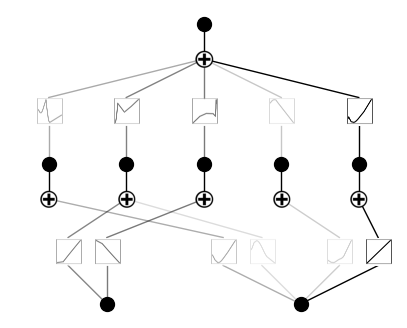

In [5]:
model = model.prune()
model.plot()
# train again after pruning
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)

saving model version 0.4


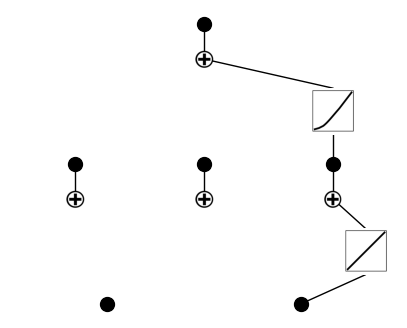

In [6]:
model = model.prune()
model.plot()

| train_loss: 5.31e-01 | test_loss: 5.31e-01 | reg: 3.36e-01 | : 100%|█| 50/50 [00:43<00:00,  1.15it


saving model version 0.5
saving model version 0.6
saving model version 0.7


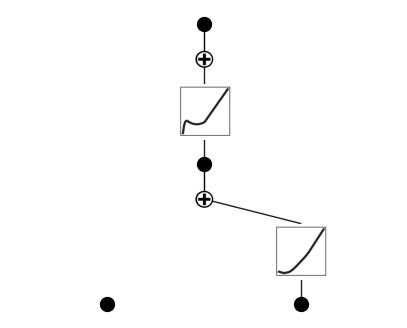

In [7]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model = model.prune()
model.plot()
model = model.refine(10)

| train_loss: 5.31e-01 | test_loss: 5.31e-01 | reg: 3.72e-01 | : 100%|█| 50/50 [00:52<00:00,  1.04s/


saving model version 0.8
saving model version 0.9


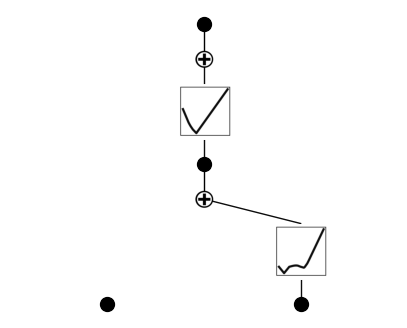

In [8]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model = model.prune()
model.plot()

In [9]:
lib = SYMBOLIC_LIB  # candidate libraries from SYMBOLIC_LIB
model.auto_symbolic(lib=lib)  # automatically select the best sign function
formula = model.symbolic_formula()[0][0]
nsimplify(ex_round(formula, 4))
ex_round(formula, 4)

fixing (0,0,0) with 0
fixing (0,1,0) with 0, r2=0.0, c=0
fixing (1,0,0) with 0, r2=0.0, c=0
saving model version 0.10


0.3707